# BERTopic: topic visualization and labeling

In this notebook we:

1. load the corpus,
2. train a BERTopic model,
3. remove multilingual stopwords from topic words,
4. inspect and visualize topics,
5. investigate topics for one person,
6. create short topic labels with Qwen.



## 1. Setup

The first two cells are specific to Google Colab and Google Drive. Change the folder if your notebook or data are stored elsewhere.


In [1]:
# Colab only
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/13_brozic_scholger_wolff_finetuning_visualization/


/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/13_brozic_scholger_wolff_finetuning_visualization


In [3]:
!pip install -q bertopic wordcloud stopwordsiso transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 8.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud


## 2. Load the corpus

Each row in `df` is one paragraph from a letter from the Hugo Schuchardt Archive (HSA). BERTopic will therefore assign a topic to each paragraph.


In [5]:
df = pd.read_csv('../../datasets/hsa/letters_full.csv')
df.head()


,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,word_count
0,hsa.letter.1.xml,L.1-1,https://gams.uni-graz.at/o:hsa.persons#P.1069,Baissac,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1885-01-20,Ma Doudou vous envoie une petite brochure jaun...,fr,NaN,17
1,hsa.letter.1.xml,L.1-2,https://gams.uni-graz.at/o:hsa.persons#P.1069,Baissac,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1885-01-20,Nous sommes anxieux l’un et l’autre d’avoir de...,fr,NaN,31
2,hsa.letter.3.xml,L.3-1,https://gams.uni-graz.at/o:hsa.persons#P.1068,Bähr,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1924-04-22,Bereits 5 Tage nach Abgang meines letzten Brie...,de,Revue de Linguistique Romane; Verlage; Euskalt...,124
3,hsa.letter.3.xml,L.3-2-1,https://gams.uni-graz.at/o:hsa.persons#P.1068,Bähr,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1924-04-22,"Was die deutsche Verlagswelt angeht, so muss i...",de,Revue de Linguistique Romane; Verlage; Euskalt...,511
4,hsa.letter.3.xml,L.3-2-2,https://gams.uni-graz.at/o:hsa.persons#P.1068,Bähr,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1924-04-22,"sicherlich viel verdankt— erklärt, er wolle di...",de,Revue de Linguistique Romane; Verlage; Euskalt...,46


In [6]:
# Keep only rows that contain text
df = df.dropna(subset=["text"]).reset_index(drop=True)
docs = df["text"].astype(str).tolist()

print("Documents for BERTopic:", len(docs))

topic_model = BERTopic(
    language="multilingual",
    min_topic_size=20,  ############# ADJUST #############
    verbose=True
)

topics, probabilities = topic_model.fit_transform(docs)

# Save each paragraph's topic in the dataframe.
# We use this later for the per-person investigation.
df["topic"] = topics


2026-09-24 14:30:49,581 - BERTopic - Embedding - Transforming documents to embeddings.


Documents for BERTopic: 42344


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1324 [00:00<?, ?it/s]

2026-09-24 14:32:21,810 - BERTopic - Embedding - Completed ✓
2026-09-24 14:32:21,811 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-24 14:33:22,468 - BERTopic - Dimensionality - Completed ✓
2026-09-24 14:33:22,470 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-24 14:33:30,543 - BERTopic - Cluster - Completed ✓
2026-09-24 14:33:30,565 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-24 14:33:34,587 - BERTopic - Representation - Completed ✓


In [7]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,24743,-1_ich_die_in_der,"[ich, die, in, der, und, de, zu, sie, nicht, von]",[Aber Sie denken vielleicht dass ich Ihnen hie...
1,0,2665,0_di_eta_la_il,"[di, eta, la, il, si, da, che, con, un, ta]","[Una volta, quando ero bambino, nel baule di u..."
2,1,1420,1_deutschen_die_der_in,"[deutschen, die, der, in, und, das, nicht, den...",[Indem ich Ihnen für Ihren liebenswürdigen Bri...
3,2,1393,2_basque_the_baskischen_of,"[basque, the, baskischen, of, baskische, de, t...",[so you disdain to give your reasons for not a...
4,3,974,3_dank_für_ihnen_sie,"[dank, für, ihnen, sie, ihre, herzlichen, vous...",[Nehmen Sie meinen herzlichen Dank für Ihre gü...
...,...,...,...,...,...
105,104,22,104_ti_hausherrn_sie_nicht,"[ti, hausherrn, sie, nicht, casa, bin, wohnung...",[Was das Hauskaufen angeht so thut da erfahrun...
106,105,22,105_frisches_grün_ihm_er,"[frisches, grün, ihm, er, conservis, ausgespro...","[Um ihm frisches Grün zu geben,, Um ihm frisch..."
107,106,22,106_madras_of_the_india,"[madras, of, the, india, esq, bombay, bishop, ...","[- The Rev.d W. Miller, Principal of the Madra..."
108,107,20,107_er_müller_ihn_meyer,"[er, müller, ihn, meyer, non, prof, di, tuoi, ...",[Meyers Bibliothek dürfte nicht Weniges enthal...


## 3. Remove stopwords from topic words

BERTopic first creates the document clusters. We then update the **topic representations** with multilingual stopwords removed.

This is important for the later exercises: both the **per-person topic investigation** and the **Qwen labels** use these cleaned topic words.


In [8]:
import stopwordsiso


In [9]:
def get_stopwords(languages):
    """Collect stopwords for all language codes found in the corpus."""
    stopwords = set()

    for language in languages:
        if isinstance(language, str) and stopwordsiso.has_lang(language):
            stopwords.update(stopwordsiso.stopwords(language))

    return stopwords


In [10]:
# Languages that occur in the corpus
corpus_languages = df["language"].dropna().unique().tolist()

# Build one multilingual stopword set
multiling_stop_words = get_stopwords(corpus_languages)

print(f"Languages: {corpus_languages}")
print(f"Number of stopwords: {len(multiling_stop_words)}")


Languages: ['fr', 'de', 'es', 'eu', 'da', 'pt', 'it', 'nl', 'ft', 'en', 'ca', 'la', 'ro', 'idb', 'cy', 'pap', 'io', 'hu', 'lad', 'ms', 'roa']
Number of stopwords: 6425


In [11]:
# Tell BERTopic not to use these stopwords in topic representations
vectorizer_model = CountVectorizer(stop_words=list(multiling_stop_words))

topic_model.update_topics(
    docs,
    vectorizer_model=vectorizer_model
)


In [12]:
# Topic words are now stopword-filtered

############# ADJUST: get the topic info #############

topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,24743,-1_bitte_schreiben_arbeit_lassen,"[bitte, schreiben, arbeit, lassen, sagen, erha...",[Aber Sie denken vielleicht dass ich Ihnen hie...
1,0,2665,0_zure_maglie_rete_fuso,"[zure, maglie, rete, fuso, filo, maglia, vgl, ...","[Una volta, quando ero bambino, nel baule di u..."
2,1,1420,1_deutschen_deutsche_deutschland_deutsch,"[deutschen, deutsche, deutschland, deutsch, de...",[Indem ich Ihnen für Ihren liebenswürdigen Bri...
3,2,1393,2_basque_baskischen_baskische_basques,"[basque, baskischen, baskische, basques, baski...",[so you disdain to give your reasons for not a...
4,3,974,3_herzlichen_danke_herzlichsten_monsieur,"[herzlichen, danke, herzlichsten, monsieur, bi...",[Nehmen Sie meinen herzlichen Dank für Ihre gü...
...,...,...,...,...,...
105,104,22,104_hausherrn_casa_häuser_wohnung,"[hausherrn, casa, häuser, wohnung, eitel, baue...",[Was das Hauskaufen angeht so thut da erfahrun...
106,105,22,105_frisches_grün_conservis_illes,"[frisches, grün, conservis, illes, ausgesproch...","[Um ihm frisches Grün zu geben,, Um ihm frisch..."
107,106,22,106_madras_esq_bombay_bishop,"[madras, esq, bombay, bishop, calcutta, secret...","[- The Rev.d W. Miller, Principal of the Madra..."
108,107,20,107_müller_meyer_prof_theo,"[müller, meyer, prof, theo, vorlesungen, kelle...",[Meyers Bibliothek dürfte nicht Weniges enthal...


In [13]:
# Inspect one cleaned topic

############# ADJUST: inspect a specific topic #############
topic_model.get_topic(1)


[('deutschen', np.float64(0.021390255920077834)),
 ('deutsche', np.float64(0.012947060697319606)),
 ('deutschland', np.float64(0.009230949497680425)),
 ('deutsch', np.float64(0.00834170534186607)),
 ('deutscher', np.float64(0.007148294806621392)),
 ('berlin', np.float64(0.005150262876185785)),
 ('polen', np.float64(0.005032668606816258)),
 ('sagen', np.float64(0.005003218281980558)),
 ('allemagne', np.float64(0.004684131431989917)),
 ('allemand', np.float64(0.004497593806849976))]

In [14]:
# Optional safety check: remove stopwords again whenever we extract topic words
def clean_topic_words(topic_number, n_words=10):
    words = [word for word, _ in topic_model.get_topic(topic_number)]
    return [word for word in words if word.lower() not in multiling_stop_words][:n_words]

clean_topic_words(3)


['herzlichen',
 'danke',
 'herzlichsten',
 'monsieur',
 'bitte',
 'bestens',
 'wünsche',
 'dankt',
 'glückwünsche',
 'grüße']

## 4. Simple topic labels

We can create short labels from the cleaned BERTopic representations. Because the topic model was updated with our stopword list, these labels are based on words without stopwords.


In [33]:
topic_labels = topic_model.generate_topic_labels(
    nr_words=5,
    topic_prefix=False,
    separator=" , "
)

topic_model.set_topic_labels(topic_labels)


############# ADJUST: nr_words and the seperator. Try to manually label the topics, it has to be a number: value pair#############


In [34]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,24743,-1_bitte_schreiben_arbeit_lassen,"bitte , schreiben , arbeit , lassen , sagen","[bitte, schreiben, arbeit, lassen, sagen, erha...",[Aber Sie denken vielleicht dass ich Ihnen hie...
1,0,2665,0_zure_maglie_rete_fuso,"zure , maglie , rete , fuso , filo","[zure, maglie, rete, fuso, filo, maglia, vgl, ...","[Una volta, quando ero bambino, nel baule di u..."
2,1,1420,1_deutschen_deutsche_deutschland_deutsch,"deutschen , deutsche , deutschland , deutsch ,...","[deutschen, deutsche, deutschland, deutsch, de...",[Indem ich Ihnen für Ihren liebenswürdigen Bri...
3,2,1393,2_basque_baskischen_baskische_basques,"basque , baskischen , baskische , basques , ba...","[basque, baskischen, baskische, basques, baski...",[so you disdain to give your reasons for not a...
4,3,974,3_herzlichen_danke_herzlichsten_monsieur,"herzlichen , danke , herzlichsten , monsieur ,...","[herzlichen, danke, herzlichsten, monsieur, bi...",[Nehmen Sie meinen herzlichen Dank für Ihre gü...
...,...,...,...,...,...,...
105,104,22,104_hausherrn_casa_häuser_wohnung,"hausherrn , casa , häuser , wohnung , eitel","[hausherrn, casa, häuser, wohnung, eitel, baue...",[Was das Hauskaufen angeht so thut da erfahrun...
106,105,22,105_frisches_grün_conservis_illes,"frisches , grün , conservis , illes , ausgespr...","[frisches, grün, conservis, illes, ausgesproch...","[Um ihm frisches Grün zu geben,, Um ihm frisch..."
107,106,22,106_madras_esq_bombay_bishop,"madras , esq , bombay , bishop , calcutta","[madras, esq, bombay, bishop, calcutta, secret...","[- The Rev.d W. Miller, Principal of the Madra..."
108,107,20,107_müller_meyer_prof_theo,"müller , meyer , prof , theo , vorlesungen","[müller, meyer, prof, theo, vorlesungen, kelle...",[Meyers Bibliothek dürfte nicht Weniges enthal...


## 5. Visualize topics

BERTopic provides several useful visualizations. The labels stored above can be reused with `custom_labels=True`.

Try changing `top_n_topics` or the number of words shown.


In [35]:
############# ADJUST: create a hierarchichal clustering, use the custom labels, select the number of topics  #############
hierarchical_topics = topic_model.hierarchical_topics(docs)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics,
                                top_n_topics = 10)

100%|██████████| 108/108 [00:01<00:00, 95.24it/s]


In [ ]:
############# ADJUST: create a bar chart, use the custom labels, select the number of topics  #############



In [ ]:
############# ADJUST: visualize the topics in a distance map  #############


## 6. Inspect a topic

`Topic = -1` contains paragraphs that were not assigned to one of the main clusters.


In [ ]:
topic_model.get_topic_info().head(15)


,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,26998,-1_bitte_sagen_schreiben_lassen,-1_bitte_sagen_schreiben_lassen,"[bitte, sagen, schreiben, lassen, arbeit, erha...","[Ihre Bitte um Fabeln, Liedchen [,] Sprichwört..."
1,0,1681,0_wort_vgl_zure_georg,Word meaning,"[wort, vgl, zure, georg, bedeutet, bedeutung, ...","[kymrisch eirin entspricht ir. airne , sodass ..."
2,1,1353,1_basque_baskischen_baskische_basques,Basque,"[basque, baskischen, baskische, basques, baski...",[at last I am able to thank you for and reply ...
3,2,1328,2_maglie_rete_filo_fuso,Writing,"[maglie, rete, filo, fuso, maglia, lunghezza, ...",[una camera che misura una lunghezza al centro...
4,3,765,3_lettre_carta_briefe_schreiben,German,"[lettre, carta, briefe, schreiben, carte, brie...","[Haben Sie meinen Brief erhalten?, Dank für Ih..."
5,4,605,4_madrid_spanien_sevilla_vd,4_madrid_spanien_sevilla_vd,"[madrid, spanien, sevilla, vd, spanischen, jua...",[Es el caso que con el objeto de promover en l...
6,5,379,5_wissenschaft_wissenschaftlichen_science_glaube,5_wissenschaft_wissenschaftlichen_science_glaube,"[wissenschaft, wissenschaftlichen, science, gl...","[Sie hatten, väterlicher Freund und Berater, i..."
7,6,331,6_wien_leipzig_berlin_1856,6_wien_leipzig_berlin_1856,"[wien, leipzig, berlin, 1856, 1885, 1893, schl...","[Max Moltke, Deutscher Sprachwart. Zeitschr. f..."
8,7,316,7_comité_akademie_mitglied_fakultät,7_comité_akademie_mitglied_fakultät,"[comité, akademie, mitglied, fakultät, univers...",[Du wirst verwundert sein dass ich meinen Stan...
9,8,297,8_russischen_russische_georgische_georgischen,8_russischen_russische_georgische_georgischen,"[russischen, russische, georgische, georgische...","[In Ihrer Dorpater Antrittsvorlesung, welche m..."


Choose one topic number from the table and inspect its most important words.


In [ ]:
topic_number = 0

topic_model.get_topic(topic_number)


[('wort', np.float64(0.008053331396957073)),
 ('vgl', np.float64(0.007399669814075245)),
 ('zure', np.float64(0.0067639435618437466)),
 ('georg', np.float64(0.005153729494806309)),
 ('bedeutet', np.float64(0.0050575461650807525)),
 ('bedeutung', np.float64(0.004953006700170149)),
 ('sp', np.float64(0.004681955927649796)),
 ('azkue', np.float64(0.004632292601348331)),
 ('lisez', np.float64(0.004561459821294168)),
 ('ital', np.float64(0.004436428099788093))]

Now read a few representative paragraphs. Do the words above describe these paragraphs well?


In [ ]:
topic_model.get_representative_docs(topic_number)[:3]


['kymrisch eirin entspricht ir. airne , sodass wir eher auf urkelt. *arinio- oder -[one] kommen. Sollte nun südwestromanisches arañón (langued., gask., arag., kat. mallork.) nicht besser darauf beruhen als auf bask. , das seinerseits ja wol ebenfalls gall. Lehnwort sein wird? Namentlich das rom. ñ käme dabei besser auf seine Rechnung. Damit würde ich gerne noch zusammenstellen, was Mistral unter arnaveu bringt, auch katal. ar, das eigentlich Plur. wäre, aber wie? – Meine Bemerkung, dass v.E. bask. andera nicht verzeichne, beruht auf einer Verwechslung. Diez giebt bask. landera ‚Feuerbock’, das offenbar Lehnwort ist aus frz; da bask. an(d)era ‚junge Frau’ in die Diskussion bezogen wurde u. ich aus Diez II. c. landier ein entsprechendes Wort für ‚F..bk’ im Gedächtnis hatte, verwechselte ich die beiden u. da ich bei v.E. nur and(e)re ‚ junge Frau’, nicht ‚F..ck’ fand u. D. nicht noch nachschlug, entstand die ja allerdings sehr dumme Bemerkung.',
 'Obwohl ich gar nichts zur Lösung der vorg

The topic map above gives a global overview. Topics positioned close together have similar document representations.


The labels are stored in the BERTopic model, so `custom_labels=True` reuses them in later visualizations.


## 7. Word cloud

BERTopic gives us words and weights for each topic. Because we already updated the model with the multilingual stopword list, the word cloud also uses the cleaned topic representation.


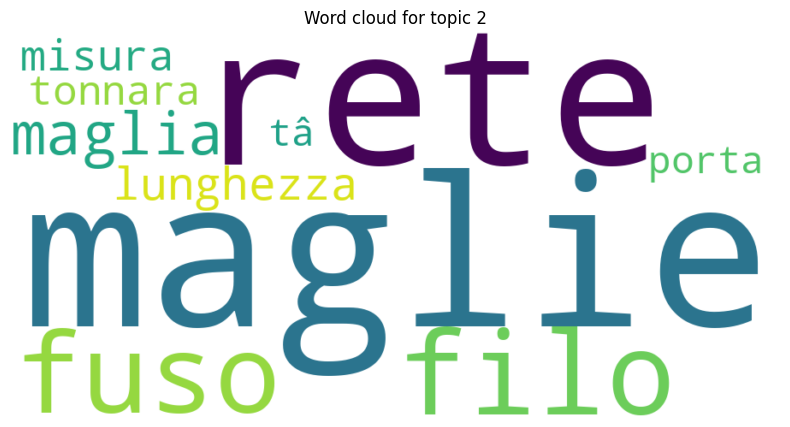

In [ ]:
topic_number = 2

topic_words = topic_model.get_topic(topic_number)
frequencies = dict(topic_words)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate_from_frequencies(frequencies)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word cloud for topic {topic_number}")
plt.show()


## 8. Investigate one sender

First, we can look at how many letters a sender has in the corpus. Then we inspect which BERTopic topics occur in that sender's paragraphs.

The topic names below are rebuilt from `clean_topic_words()`, so **stopwords are excluded from the per-person topic investigation**.


In [ ]:
letters_per_sender = df.groupby('sender')['source_file'].nunique().sort_values(ascending=False)
display(letters_per_sender.head(10))

,source_file
sender,
Schuchardt,2441
Spitzer,471
Urquijo Ybarra,243
Lacombe,233
Gartner,222
Dodgson,181
Reinisch,166
Katona,162
Gröber,156


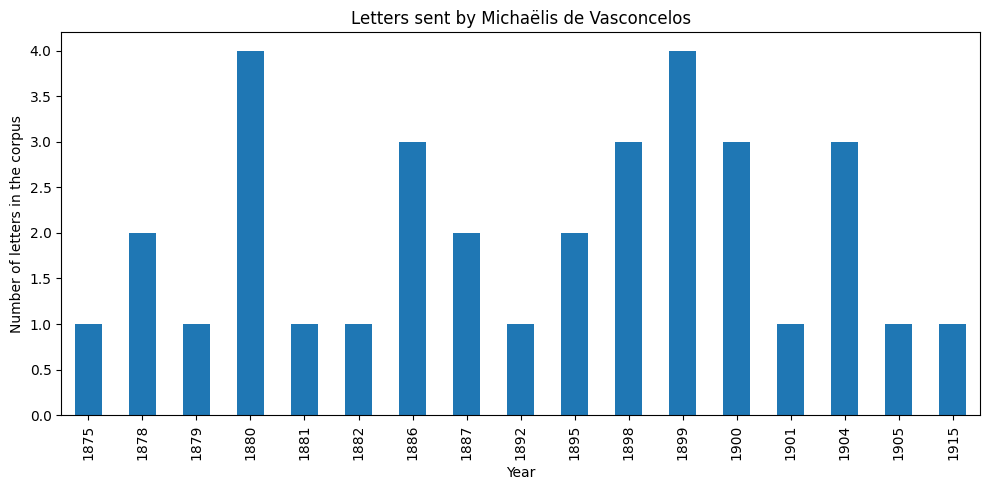

In [ ]:
# Choose a sender
sender = "Michaëlis de Vasconcelos"

# One row per letter
letters = (
    df[["source_file", "sender", "date"]]
    .drop_duplicates(subset="source_file")
)

sender_letters = letters[letters["sender"] == sender].copy()
sender_letters["date"] = pd.to_datetime(sender_letters["date"], errors="coerce")

# Convert year to integer type after dropping NaNs to avoid the .0 suffix
sender_letters["year"] = sender_letters["date"].dt.year.astype("Int64")

letters_per_year = sender_letters["year"].value_counts().sort_index()

letters_per_year.plot(kind="bar", figsize=(10, 5))
plt.title(f"Letters sent by {sender}")
plt.xlabel("Year")
plt.ylabel("Number of letters in the corpus")
plt.tight_layout()
plt.show()

In [ ]:
PERSON = "Michaëlis de Vasconcelos"

# Count the topics in this person's paragraphs
person_topics = (
    df.loc[
        (df["sender"] == PERSON) & (df["topic"] != -1),
        "topic"
    ]
    .value_counts()
)

# Make readable labels from cleaned topic words
person_topic_labels = {
    topic: " - ".join(clean_topic_words(topic, n_words=3))
    for topic in person_topics.index
}

person_topics.index = [
    person_topic_labels[topic]
    for topic in person_topics.index
]

person_topics.index.name = "Topic (stopwords removed)"
person_topics.name = "Paragraphs"

display(person_topics)


,Paragraphs
Topic (stopwords removed),
madrid - spanien - sevilla,16
wort - vgl - zure,16
maglie - rete - filo,10
spindel - spindeln - faden,9
wien - leipzig - berlin,3
portuguez - exa - portugiesen,3
deutschen - allemand - deutsche,2
deutschen - deutschland - deutsche,2
danke - herzlichen - glückwünsche,2


## 9. Label topics with Qwen

Qwen receives only cleaned topic words. We filter them explicitly before sending them to the model, so stopwords cannot re-enter through the BERTopic representation.

In [ ]:
from transformers import pipeline

# Load Qwen
generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    device_map="auto"
)

# All regular topics (exclude outlier topic -1)
topic_numbers = [
    topic for topic in topic_model.get_topic_info()["Topic"]
    if topic != -1
]


def qwen_label(topic_number):
    # Explicitly use stopword-free topic words
    words = clean_topic_words(topic_number, n_words=5)

    messages = [{
        "role": "user",
        "content": (
            "Create a short, human-readable topic label for these keywords: "
            f"{', '.join(words)}. "
            "Return only the label, maximum 3 words."
        )
    }]

    result = generator(
        messages,
        max_new_tokens=10,
        do_sample=False
    )

    return result[0]["generated_text"][-1]["content"].strip()


# Generate one Qwen label per topic
qwen_labels = {
    topic: qwen_label(topic)
    for topic in topic_numbers
}

topic_model.set_topic_labels(qwen_labels)

# Show exactly which cleaned words Qwen received
qwen_results = pd.DataFrame({
    "Topic": topic_numbers,
    "CleanWords": [clean_topic_words(topic, n_words=5) for topic in topic_numbers],
    "QwenLabel": [qwen_labels[topic] for topic in topic_numbers]
})

display(qwen_results)

# Visualize with Qwen labels
topic_model.visualize_hierarchy(
    custom_labels=True,
    top_n_topics=30
)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=10) a

,Topic,CleanWords,QwenLabel
0,0,"[wort, vgl, zure, georg, bedeutet]",Wort-Verwendungsgenehmigung-Z
1,1,"[basque, baskischen, baskische, basques, baski...",Basque people/Basque language
2,2,"[maglie, rete, filo, fuso, maglia]",Clothing Threads Timeline
3,3,"[lettre, carta, briefe, schreiben, carte]",Letter writing
4,4,"[madrid, spanien, sevilla, vd, spanischen]","""Spain Cities Tour"""
...,...,...,...
119,119,"[tschechen, böhmen, tschechischen, staates, ru...",Czech Republic Slovakia Romania
120,120,"[wörterbuch, dictionnaire, lhande, dictionary,...",Efik Dictionary Lhande Wörterbuch
121,121,"[morolf, häßlich, geständniß, vater, gedicht]","""Poetry of shame and fatherhood"""
122,122,"[medios, sciences, science, soñando, acudiré]",Dreaming of Science Journalism
